# Spectral Gap Correlation — Graph Topology Predicts Sink Strength? (GRIT)

**H5:** Does graph topology (spectral gap lambda_2) predict sink formation?

Using GRIT (pure Transformer, no MPNN), this is a cleaner test than GPS since
the only mixing channel is global attention.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import spearmanr
import yaml
from tqdm import tqdm

from src.grit_model import InstrumentedGRIT
from src.datasets import get_dataloaders, DATASET_INFO, compute_spectral_properties
from src.metrics import compute_sink_scores
from src.diagnostics import load_diagnostics, aggregate_metrics

matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 150,
                             'axes.spines.top': False, 'axes.spines.right': False})

OUTPUTS_DIR = '../outputs'
FIGURES_DIR = '../outputs/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
def load_experiment(experiment_id, device):
    config_path = os.path.join(OUTPUTS_DIR, experiment_id, 'config.yaml')
    with open(config_path) as f:
        config = yaml.safe_load(f)
    dataset_info = DATASET_INFO[config['data']['dataset']].copy()
    vnode_cfg = config.get('vnode', {})
    if vnode_cfg.get('enabled', False) and dataset_info.get('num_node_types') is not None:
        dataset_info['num_node_types'] = dataset_info['num_node_types'] + 1
        dataset_info['num_edge_types'] = dataset_info['num_edge_types'] + 1
    model = InstrumentedGRIT(config, dataset_info).to(device)
    model.load_state_dict(torch.load(
        os.path.join(OUTPUTS_DIR, experiment_id, 'best_model.pt'),
        map_location=device, weights_only=True))
    model.eval()
    return model, config, dataset_info

## 1. Per-graph spectral gap vs sink strength

In [3]:
@torch.no_grad()
def compute_per_graph_spectral_and_sinks(model, config, device, max_graphs=200):
    _, _, test_loader, _ = get_dataloaders(config)
    model.eval()
    per_graph = []
    graphs_done = 0
    for batch in tqdm(test_loader, desc='Per-graph spectral + sinks'):
        if graphs_done >= max_graphs: break
        batch = batch.to(device)
        _ = model(batch, collect_diagnostics=True)
        batch_ids = model.layer_data[0]['batch']
        for g_idx, g_id in enumerate(batch_ids.unique()):
            if graphs_done >= max_graphs: break
            graph_mask = (batch_ids == g_id)
            num_nodes_g = graph_mask.sum().item()
            node_indices = torch.where(graph_mask)[0]
            g_edges = batch.edge_index[:, batch.batch[batch.edge_index[0]] == g_id]
            local_map = {int(n): i for i, n in enumerate(node_indices)}
            local_edges = [[local_map[s], local_map[d]] for s, d in g_edges.t().tolist()
                           if s in local_map and d in local_map]
            if not local_edges:
                graphs_done += 1; continue
            local_ei = torch.tensor(local_edges).t()
            from torch_geometric.data import Data
            spectral = compute_spectral_properties(Data(edge_index=local_ei, num_nodes=num_nodes_g))
            last_layer = len(model.attn_weights) - 1
            attn_full = model.attn_weights[last_layer]
            if attn_full is not None and g_idx < attn_full.size(0):
                attn_g = attn_full[g_idx, :, :num_nodes_g, :num_nodes_g]
                sink_data = compute_sink_scores(attn_g)
                per_graph.append({'num_nodes': num_nodes_g, 'lambda_2': spectral['lambda_2'],
                                  'max_sink_score': sink_data['max_sink_score'],
                                  'sink_rate': sink_data['overall_sink_rate']})
            graphs_done += 1
    return per_graph

In [4]:
spectral_data = {}
for eid, desc in [('zinc-grit', 'ZINC'), ('peptides-grit', 'Peptides')]:
    if not os.path.exists(os.path.join(OUTPUTS_DIR, eid, 'best_model.pt')):
        print(f'Skipping {eid} — not trained yet')
        continue
    print(f'\n=== {desc} ===')
    model, config, _ = load_experiment(eid, device)
    spectral_data[desc] = compute_per_graph_spectral_and_sinks(model, config, device)
    del model; torch.cuda.empty_cache() if torch.cuda.is_available() else None


=== ZINC ===
  Precomputing rrwp(dim=21) for zinc/train...


  train: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:23<00:00, 428.06it/s]


  Saved to data/pe_cache/zinc_train_rrwp21.pt
  Loading cached PE for zinc/val from data/pe_cache/zinc_val_rrwp21.pt
  Loading cached PE for zinc/test from data/pe_cache/zinc_test_rrwp21.pt


Per-graph spectral + sinks:  22%|████████████████████████████████▌                                                                                                                    | 7/32 [00:01<00:03,  6.50it/s]

Skipping peptides-grit — not trained yet


### Scatter plots: lambda_2 vs sink rate, num_nodes vs sink score

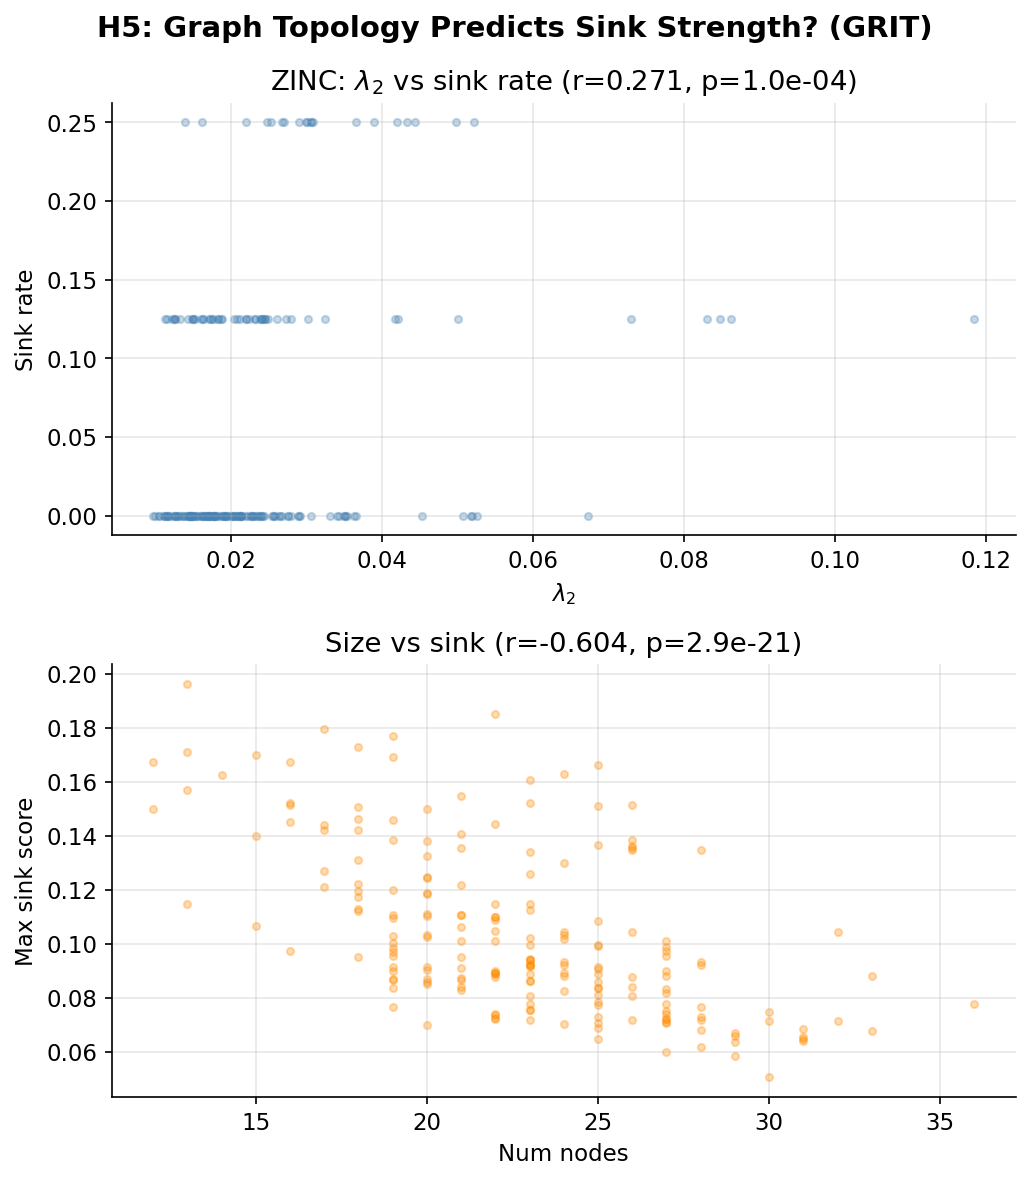

In [5]:
n_ds = len(spectral_data)
if n_ds > 0:
    fig, axes = plt.subplots(2, n_ds, figsize=(7 * n_ds, 8))
    if n_ds == 1: axes = axes[:, np.newaxis]
    for col, (ds_name, graphs) in enumerate(spectral_data.items()):
        l2 = np.array([g['lambda_2'] for g in graphs])
        sr = np.array([g['sink_rate'] for g in graphs])
        ss = np.array([g['max_sink_score'] for g in graphs])
        nn_ = np.array([g['num_nodes'] for g in graphs])
        valid = ~np.isnan(sr) & ~np.isnan(l2)
        r, p = spearmanr(l2[valid], sr[valid])
        axes[0, col].scatter(l2[valid], sr[valid], alpha=0.3, s=12, color='steelblue')
        axes[0, col].set_xlabel('$\\lambda_2$'); axes[0, col].set_ylabel('Sink rate')
        axes[0, col].set_title(f'{ds_name}: $\\lambda_2$ vs sink rate (r={r:.3f}, p={p:.1e})')
        axes[0, col].grid(True, alpha=0.3)
        r2, p2 = spearmanr(nn_, ss)
        axes[1, col].scatter(nn_, ss, alpha=0.3, s=12, color='darkorange')
        axes[1, col].set_xlabel('Num nodes'); axes[1, col].set_ylabel('Max sink score')
        axes[1, col].set_title(f'Size vs sink (r={r2:.3f}, p={p2:.1e})')
        axes[1, col].grid(True, alpha=0.3)
    plt.suptitle('H5: Graph Topology Predicts Sink Strength? (GRIT)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'fig8_spectral_gap.pdf'), bbox_inches='tight', dpi=150)
    plt.show()

### Correlation table

In [6]:
print(f"{'Dataset':<12} {'N':>5} {'lambda2 vs sink_rate':>22} {'p':>10} {'nodes vs sink_score':>22} {'p':>10}")
print('=' * 90)
for ds_name, graphs in spectral_data.items():
    l2 = np.array([g['lambda_2'] for g in graphs])
    sr = np.array([g['sink_rate'] for g in graphs])
    ss = np.array([g['max_sink_score'] for g in graphs])
    nn_ = np.array([g['num_nodes'] for g in graphs])
    valid = ~np.isnan(sr) & ~np.isnan(l2)
    r1, p1 = spearmanr(l2[valid], sr[valid])
    r2, p2 = spearmanr(nn_, ss)
    sig1 = '***' if p1 < 0.001 else ('**' if p1 < 0.01 else ('*' if p1 < 0.05 else 'ns'))
    sig2 = '***' if p2 < 0.001 else ('**' if p2 < 0.01 else ('*' if p2 < 0.05 else 'ns'))
    print(f'{ds_name:<12} {valid.sum():>5} {r1:>18.3f} {sig1:>3} {p1:>10.1e} {r2:>18.3f} {sig2:>3} {p2:>10.1e}')

Dataset          N   lambda2 vs sink_rate          p    nodes vs sink_score          p
ZINC           200              0.271 ***    1.0e-04             -0.604 ***    2.9e-21


## 2. Within-dataset: binned sink score vs graph size

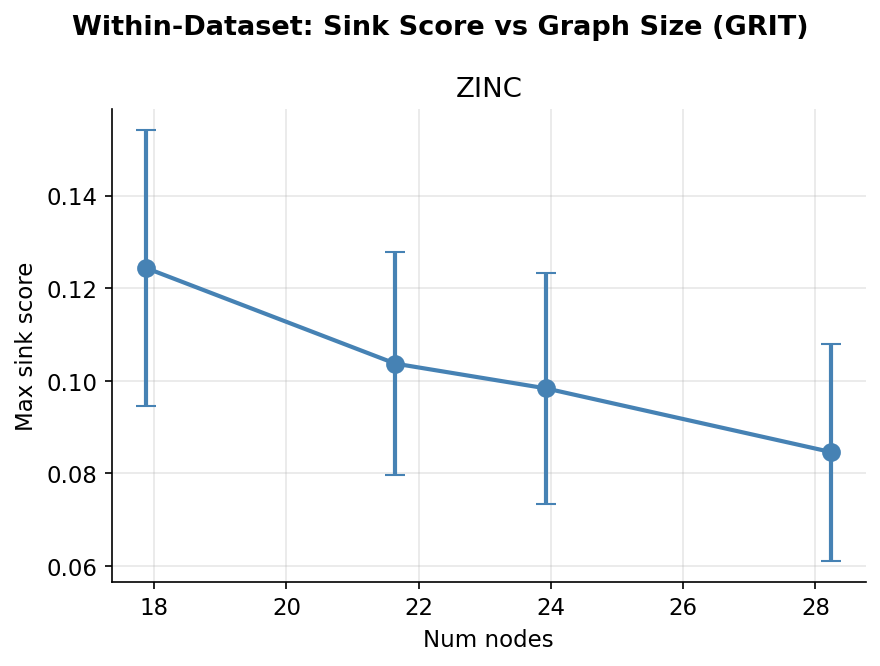

In [7]:
n_ds = len(spectral_data)
if n_ds > 0:
    fig, axes = plt.subplots(1, n_ds, figsize=(6 * n_ds, 4.5))
    if n_ds == 1: axes = [axes]
    for ax, (ds_name, graphs) in zip(axes, spectral_data.items()):
        nn_ = np.array([g['num_nodes'] for g in graphs])
        ss = np.array([g['max_sink_score'] for g in graphs])
        if len(np.unique(nn_)) > 5:
            bins = np.percentile(nn_, [0, 25, 50, 75, 100])
            centers, means, stds = [], [], []
            for i in range(4):
                mask = (nn_ >= bins[i]) & (nn_ <= bins[i+1])
                if mask.sum() > 0:
                    centers.append(nn_[mask].mean())
                    means.append(ss[mask].mean())
                    stds.append(ss[mask].std())
            ax.errorbar(centers, means, yerr=stds, fmt='o-', color='steelblue',
                       linewidth=2, markersize=8, capsize=5)
        else:
            ax.scatter(nn_, ss, alpha=0.3, s=12, color='steelblue')
        ax.set_xlabel('Num nodes'); ax.set_ylabel('Max sink score')
        ax.set_title(ds_name); ax.grid(True, alpha=0.3)
    plt.suptitle('Within-Dataset: Sink Score vs Graph Size (GRIT)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'fig9_within_dataset_size.pdf'), bbox_inches='tight', dpi=150)
    plt.show()